## K-Means Clustering

In [11]:
# ----------------------------
# 1. Import Libraries
# ----------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [12]:
# 1. Load dataset
df = pd.read_csv("C:/Users/JOSHWA/OneDrive/Desktop/CASE STUDIES/Credit Card Customer Data.csv")
df.head()

,Sl_No,Customer Key,Avg_Credit_Limit,Total_Credit_Cards,Total_visits_bank,Total_visits_online,Total_calls_made
0,1,87073,100000,2,1,1,0
1,2,38414,50000,3,0,10,9
2,3,17341,50000,7,1,3,4
3,4,40496,30000,5,1,1,4
4,5,47437,100000,6,0,12,3


In [13]:
# ----------------------------
# 3. Data Preprocessing
# ----------------------------
df = df.dropna()

# Drop identifier columns
df = df.drop(columns=["Sl_No", "Customer Key"], errors="ignore")

# Keep only numeric features
features = df.select_dtypes(include=[np.number])

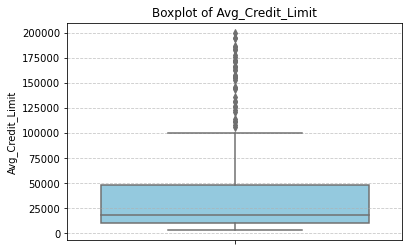

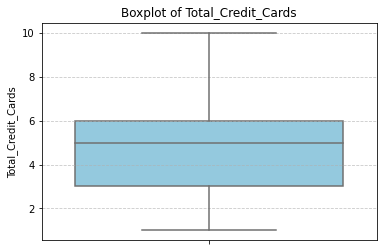

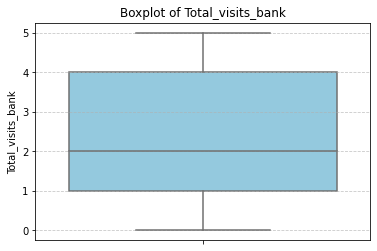

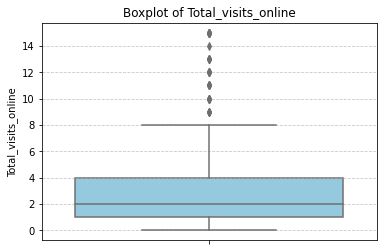

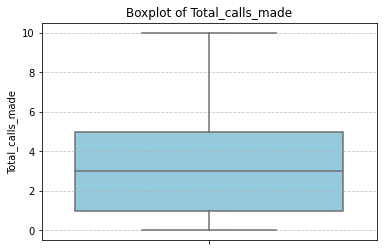

In [14]:
# ----------------------------
# 4. Feature Distributions
# ----------------------------

# Boxplots
for col in features.columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(y=features[col], color="skyblue")
    plt.title(f"Boxplot of {col}")
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.show()

In [15]:
# ----------------------------
# 5. Feature Scaling
# ----------------------------
scaler = StandardScaler()
scaled_df = scaler.fit_transform(features)

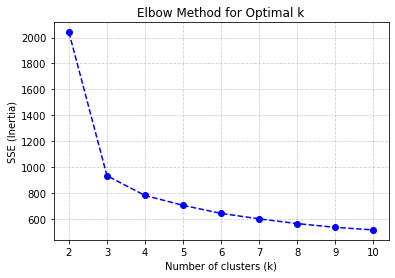

In [16]:
# ----------------------------
# 6. Elbow Method
# ----------------------------
sse = []
K = range(2,11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_df)
    sse.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K, sse, marker='o', linestyle='--', color='blue')
plt.xlabel("Number of clusters (k)")
plt.ylabel("SSE (Inertia)")
plt.title("Elbow Method for Optimal k")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

In [17]:
# ----------------------------
# 7. Silhouette Scores
# ----------------------------
silhouette_results = []
for k in range(2, 6):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(scaled_df)
    score = silhouette_score(scaled_df, labels)
    silhouette_results.append([k, round(score,3)])

# Tabulate silhouette results
print("Silhouette Scores")
print(tabulate(silhouette_results, headers=["k", "Silhouette Score"], tablefmt="fancy_grid"))

Silhouette Scores
╒═════╤════════════════════╕
│   k │   Silhouette Score │
╞═════╪════════════════════╡
│   2 │              0.418 │
├─────┼────────────────────┤
│   3 │              0.516 │
├─────┼────────────────────┤
│   4 │              0.356 │
├─────┼────────────────────┤
│   5 │              0.273 │
╘═════╧════════════════════╛


In [18]:
# ----------------------------
# 8. Run K-Means with k=3
# ----------------------------
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled_df)

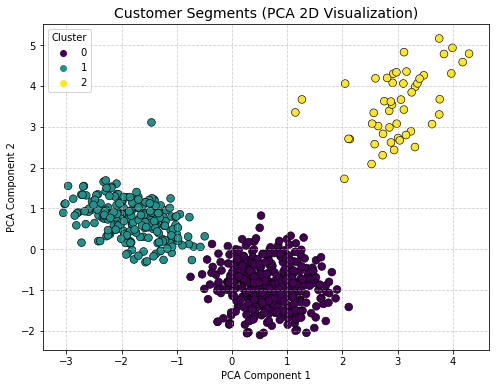

In [19]:
# ----------------------------
# 9. PCA Visualization
# ----------------------------
pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_df)

plt.figure(figsize=(8,6))
sns.scatterplot(x=pca_components[:,0], y=pca_components[:,1],
                hue=df['Cluster'], palette="viridis", s=60, edgecolor="black")
plt.title("Customer Segments (PCA 2D Visualization)", fontsize=14)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Cluster")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

In [20]:
# ----------------------------
# 10. Cluster Profile Summary
# ----------------------------
cluster_summary = df.groupby('Cluster').mean().reset_index()

# Tabulated cluster profile
print("Cluster Profile Summary (Mean Values)")
print(tabulate(cluster_summary, headers="keys", tablefmt="fancy_grid", showindex=False))

Cluster Profile Summary (Mean Values)
╒═══════════╤════════════════════╤══════════════════════╤═════════════════════╤═══════════════════════╤════════════════════╕
│   Cluster │   Avg_Credit_Limit │   Total_Credit_Cards │   Total_visits_bank │   Total_visits_online │   Total_calls_made │
╞═══════════╪════════════════════╪══════════════════════╪═════════════════════╪═══════════════════════╪════════════════════╡
│         0 │            33782.4 │              5.51554 │            3.48964  │              0.981865 │            2       │
├───────────┼────────────────────┼──────────────────────┼─────────────────────┼───────────────────────┼────────────────────┤
│         1 │            12174.1 │              2.41071 │            0.933036 │              3.55357  │            6.87054 │
├───────────┼────────────────────┼──────────────────────┼─────────────────────┼───────────────────────┼────────────────────┤
│         2 │           141040   │              8.74    │            0.6      │        

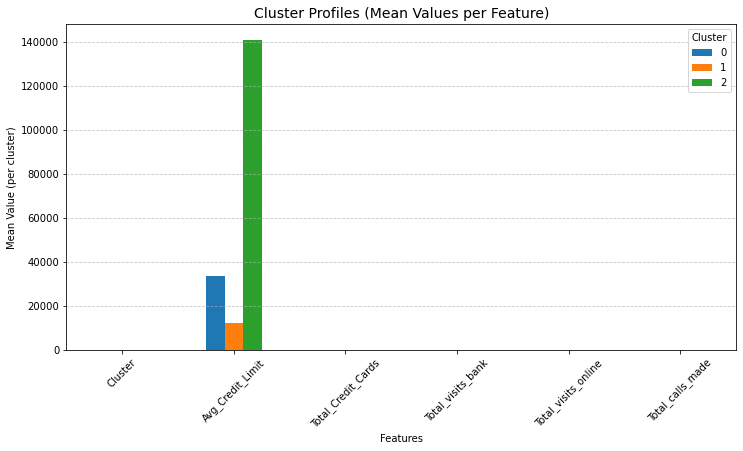

In [21]:
# ----------------------------
# 11. Cluster Profile Visualization
# ----------------------------
import matplotlib.pyplot as plt

# Plot cluster profiles (mean values per cluster)
cluster_summary.T.plot(kind='bar', figsize=(12,6))

plt.title("Cluster Profiles (Mean Values per Feature)", fontsize=14)
plt.ylabel("Mean Value (per cluster)")
plt.xlabel("Features")
plt.xticks(rotation=45)
plt.legend(title="Cluster")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

In [22]:
from sklearn.cluster import KMeans

# Run KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled_df)

print("Cluster labels assigned successfully!")

Cluster labels assigned successfully!


### Step 2: PCA for 2D Visualization

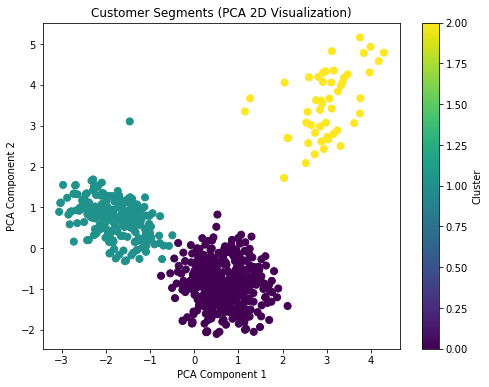

In [23]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Apply PCA to reduce dimensions to 2D
pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_df)

# Create scatter plot
plt.figure(figsize=(8,6))
plt.scatter(pca_components[:, 0], pca_components[:, 1], 
            c=df['Cluster'], cmap='viridis', s=50)

plt.title("Customer Segments (PCA 2D Visualization)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label="Cluster")
plt.show()

### Step 3: Cluster Profile Summary

In [24]:
# Mean values of each feature per cluster
cluster_summary = df.groupby('Cluster').mean()
print(cluster_summary)

         Avg_Credit_Limit  Total_Credit_Cards  Total_visits_bank  \
Cluster                                                            
0            33782.383420            5.515544           3.489637   
1            12174.107143            2.410714           0.933036   
2           141040.000000            8.740000           0.600000   

         Total_visits_online  Total_calls_made  
Cluster                                         
0                   0.981865          2.000000  
1                   3.553571          6.870536  
2                  10.900000          1.080000  


### Cluster Profile Visualization Code

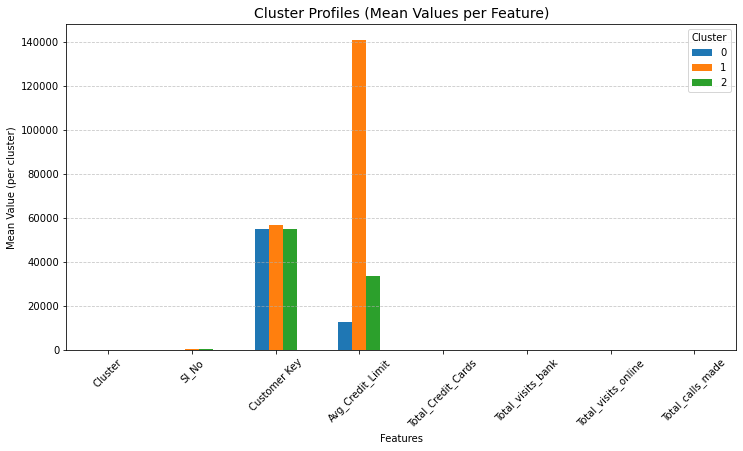

In [27]:
import matplotlib.pyplot as plt

# Plot cluster profiles (mean values per cluster)
cluster_summary.T.plot(kind='bar', figsize=(12,6))

plt.title("Cluster Profiles (Mean Values per Feature)", fontsize=14)
plt.ylabel("Mean Value (per cluster)")
plt.xlabel("Features")
plt.xticks(rotation=45)
plt.legend(title="Cluster")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

<Figure size 1080x720 with 0 Axes>

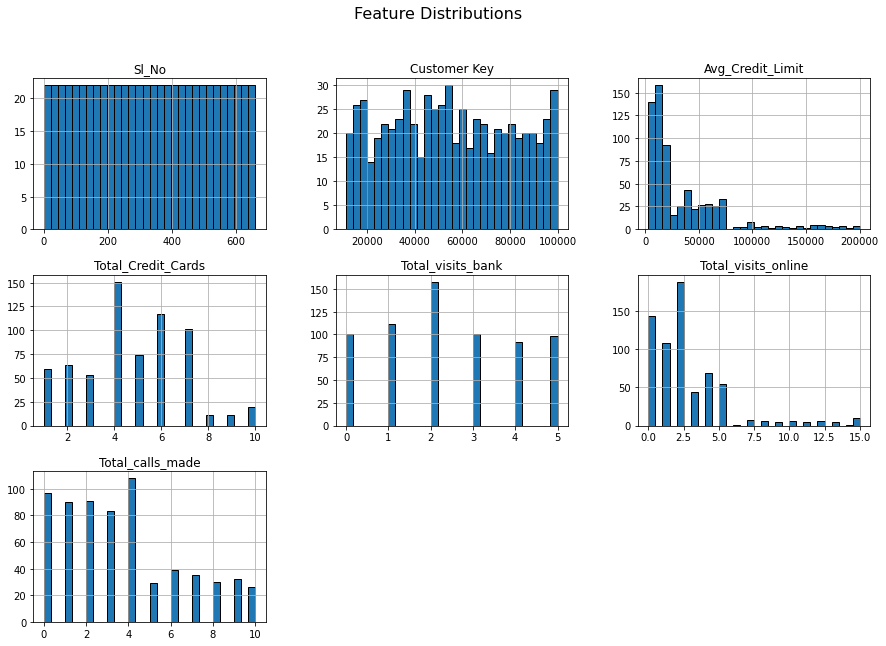

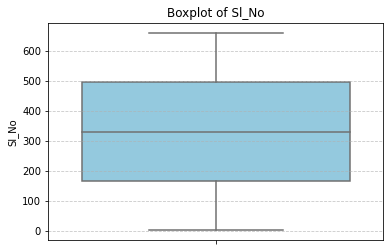

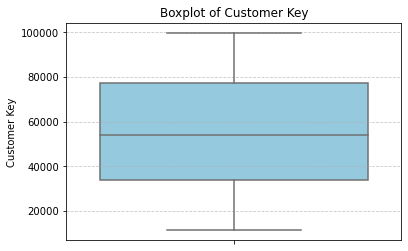

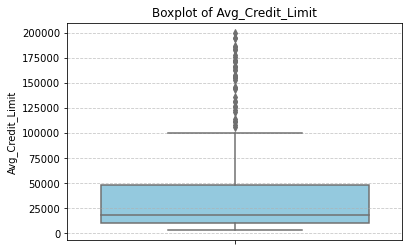

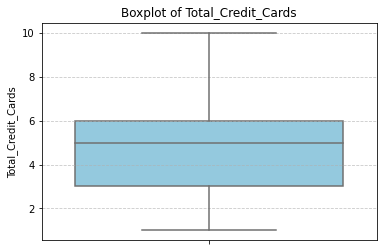

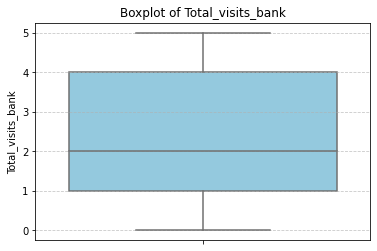

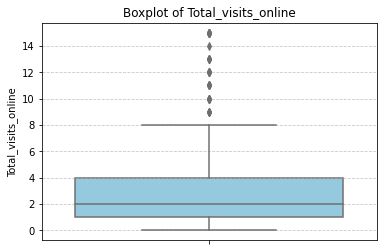

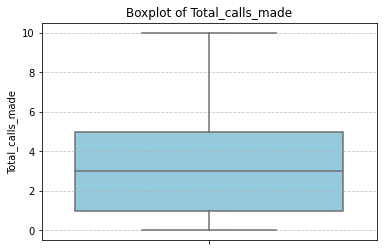

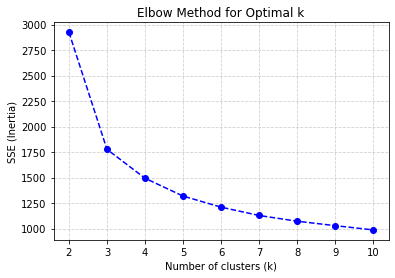

📊 Silhouette Scores
╒═════╤════════════════════╕
│   k │   Silhouette Score │
╞═════╪════════════════════╡
│   2 │              0.375 │
├─────┼────────────────────┤
│   3 │              0.444 │
├─────┼────────────────────┤
│   4 │              0.324 │
├─────┼────────────────────┤
│   5 │              0.267 │
╘═════╧════════════════════╛


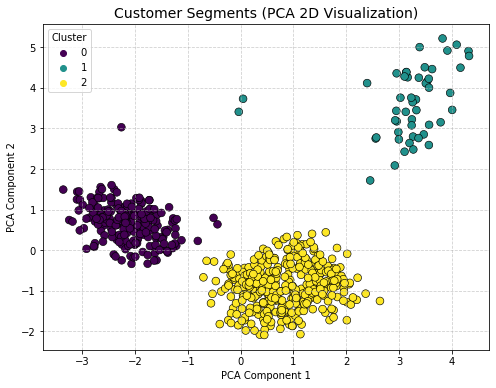

📊 Cluster Profile Summary (Mean Values)
╒═══════════╤═════════╤════════════════╤════════════════════╤══════════════════════╤═════════════════════╤═══════════════════════╤════════════════════╕
│   Cluster │   Sl_No │   Customer Key │   Avg_Credit_Limit │   Total_Credit_Cards │   Total_visits_bank │   Total_visits_online │   Total_calls_made │
╞═══════════╪═════════╪════════════════╪════════════════════╪══════════════════════╪═════════════════════╪═══════════════════════╪════════════════════╡
│         0 │  115.46 │        55072.9 │            12831.9 │              2.43363 │            0.929204 │              3.5354   │            6.82743 │
├───────────┼─────────┼────────────────┼────────────────────┼──────────────────────┼─────────────────────┼───────────────────────┼────────────────────┤
│         1 │  611.28 │        56708.8 │           141040   │              8.74    │            0.6      │             10.9      │            1.08    │
├───────────┼─────────┼────────────────┼────────

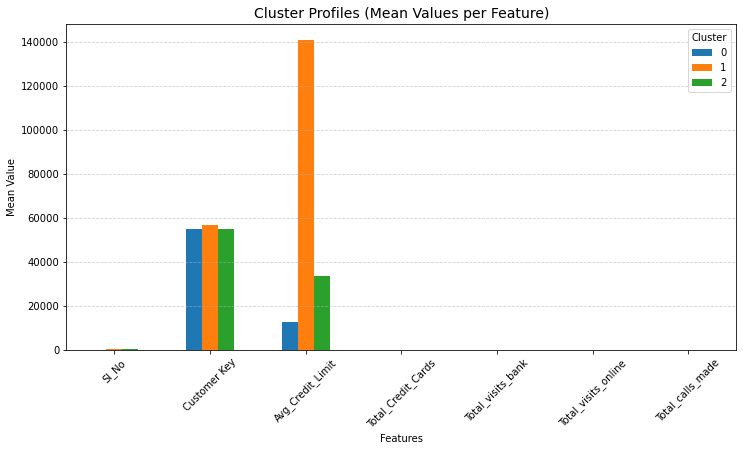

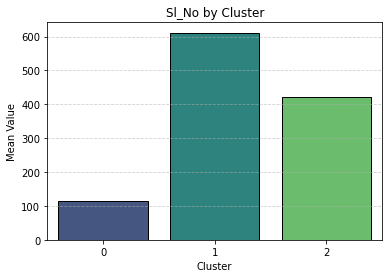

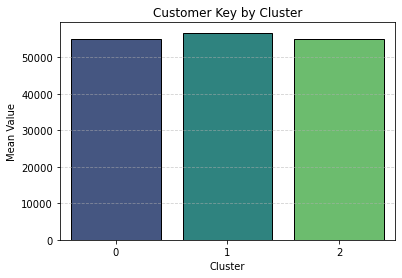

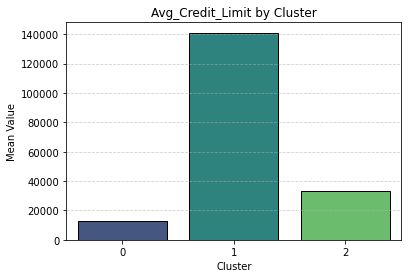

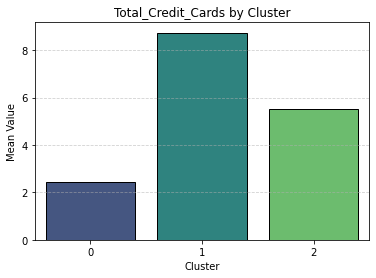

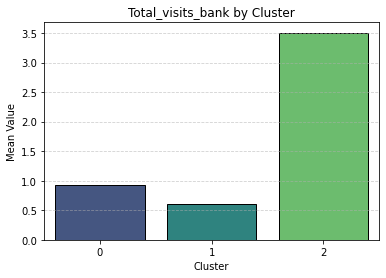

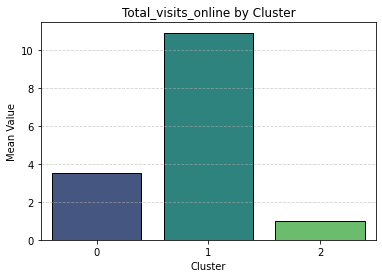

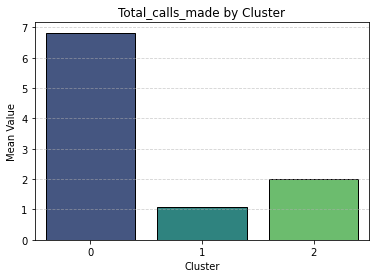

📊 Cluster Interpretation
╒═══════════╤════════════════════════════════════════════╤════════════════════════════╕
│ Cluster   │ Key Features                               │ Customer Type              │
╞═══════════╪════════════════════════════════════════════╪════════════════════════════╡
│ Cluster 0 │ Low Credit, Few Cards, High Calls          │ Phone-Dependent Users      │
├───────────┼────────────────────────────────────────────┼────────────────────────────┤
│ Cluster 1 │ High Credit, Many Cards, High Online Usage │ Premium Digital Customers  │
├───────────┼────────────────────────────────────────────┼────────────────────────────┤
│ Cluster 2 │ Moderate Credit, More Bank Visits          │ Branch-Dependent Customers │
╘═══════════╧════════════════════════════════════════════╧════════════════════════════╛


In [28]:
# ----------------------------
# 1. Import Libraries
# ----------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# ----------------------------
# 2. Load Dataset
# ----------------------------
df = pd.read_csv("C:/Users/JOSHWA/OneDrive/Desktop/CASE STUDIES/Credit Card Customer Data.csv")

# ----------------------------
# 3. Data Preprocessing
# ----------------------------
df = df.dropna()
features = df.select_dtypes(include=[np.number])

# ----------------------------
# 4. Feature Distributions
# ----------------------------
plt.figure(figsize=(15,10))
features.hist(bins=30, figsize=(15,10), edgecolor="black")
plt.suptitle("Feature Distributions", fontsize=16)
plt.show()

# Boxplots
for col in features.columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(y=features[col], color="skyblue")
    plt.title(f"Boxplot of {col}")
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.show()

# ----------------------------
# 5. Feature Scaling
# ----------------------------
scaler = StandardScaler()
scaled_df = scaler.fit_transform(features)

# ----------------------------
# 6. Elbow Method
# ----------------------------
sse = []
K = range(2,11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_df)
    sse.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K, sse, marker='o', linestyle='--', color='blue')
plt.xlabel("Number of clusters (k)")
plt.ylabel("SSE (Inertia)")
plt.title("Elbow Method for Optimal k")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

# ----------------------------
# 7. Silhouette Scores
# ----------------------------
silhouette_results = []
for k in range(2, 6):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(scaled_df)
    score = silhouette_score(scaled_df, labels)
    silhouette_results.append([k, round(score,3)])

# Tabulate silhouette results
print("📊 Silhouette Scores")
print(tabulate(silhouette_results, headers=["k", "Silhouette Score"], tablefmt="fancy_grid"))

# ----------------------------
# 8. Run K-Means with k=3
# ----------------------------
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(scaled_df)

# ----------------------------
# 9. PCA Visualization
# ----------------------------
pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_df)

plt.figure(figsize=(8,6))
sns.scatterplot(x=pca_components[:,0], y=pca_components[:,1],
                hue=df['Cluster'], palette="viridis", s=60, edgecolor="black")
plt.title("Customer Segments (PCA 2D Visualization)", fontsize=14)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Cluster")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

# ----------------------------
# 10. Cluster Profile Summary
# ----------------------------
cluster_summary = df.groupby('Cluster').mean().reset_index()

# Tabulated cluster profile
print("📊 Cluster Profile Summary (Mean Values)")
print(tabulate(cluster_summary, headers="keys", tablefmt="fancy_grid", showindex=False))

# ----------------------------
# 11. Cluster Profile Visualization
# ----------------------------
# Grouped bar chart
cluster_summary.set_index("Cluster").T.plot(kind="bar", figsize=(12,6), rot=45)
plt.title("Cluster Profiles (Mean Values per Feature)", fontsize=14)
plt.ylabel("Mean Value")
plt.xlabel("Features")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.legend(title="Cluster")
plt.show()

# Individual bar charts
for feature in cluster_summary.columns[1:]:
    plt.figure(figsize=(6,4))
    sns.barplot(x="Cluster", y=feature, data=cluster_summary,
                palette="viridis", edgecolor="black")
    plt.title(f"{feature} by Cluster")
    plt.ylabel("Mean Value")
    plt.grid(axis="y", linestyle="--", alpha=0.6)
    plt.show()

# ----------------------------
# 12. Cluster Interpretation (Business Meaning)
# ----------------------------
cluster_interpretation = [
    ["Cluster 0", "Low Credit, Few Cards, High Calls", "Phone-Dependent Users"],
    ["Cluster 1", "High Credit, Many Cards, High Online Usage", "Premium Digital Customers"],
    ["Cluster 2", "Moderate Credit, More Bank Visits", "Branch-Dependent Customers"]
]

print("📊 Cluster Interpretation")
print(tabulate(cluster_interpretation, headers=["Cluster", "Key Features", "Customer Type"], tablefmt="fancy_grid"))
